In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats as sp_stats
from scipy.optimize import curve_fit
from scipy.stats import t, spearmanr, pearsonr

plt.rcParams['svg.fonttype'] = 'none'

In [2]:
construct_stats = pd.read_csv('../../Data/Figures_2-3-4/constructs_df.csv')
# drop rows where 'construct' contains 'GS'
construct_stats = construct_stats[~construct_stats['construct'].astype(str).str.contains('GS', na=False)]
construct_stats['construct'] = construct_stats['construct'].astype(int)

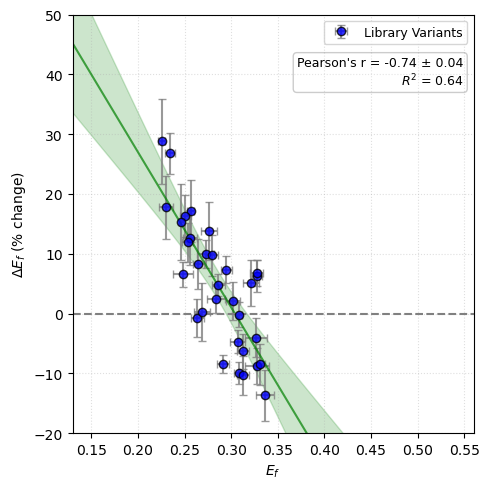

In [3]:
construct_stats['Ef_cell_perc_change'] = construct_stats['Ef_cell_delta'] / construct_stats['Ef_cell'] * 100
construct_stats['Ef_cell_perc_change_std'] = abs(construct_stats['Ef_cell_perc_change']) * np.sqrt(
    (construct_stats['Ef_cell_delta_std'] / construct_stats['Ef_cell_delta'])**2 + 
    (construct_stats['Ef_cell_std'] / construct_stats['Ef_cell'])**2
)

# Filter to only library variants (construct < 33)
library_stats = construct_stats[construct_stats['construct'] < 33].copy()

# Prepare data for fitting
fit_data = library_stats[['Ef_cell', 'Ef_cell_perc_change']].dropna()
x_data = fit_data['Ef_cell'].values
y_data = fit_data['Ef_cell_perc_change'].values

# Monte Carlo sampling for Pearson correlation
n_iterations = 1000
pearson_values = []

for _ in range(n_iterations):
    sampled_x = []
    sampled_y = []
    
    for idx, row in fit_data.iterrows():
        # Sample from normal distributions based on mean and std for each construct
        sampled_x_val = np.random.normal(library_stats.loc[idx, 'Ef_cell'], 
                                        library_stats.loc[idx, 'Ef_cell_std'])
        sampled_y_val = np.random.normal(library_stats.loc[idx, 'Ef_cell_perc_change'], 
                                         library_stats.loc[idx, 'Ef_cell_perc_change_std'])
        
        sampled_x.append(sampled_x_val)
        sampled_y.append(sampled_y_val)
    
    # Calculate Pearson correlation for this iteration
    if len(sampled_x) == len(fit_data):
        pearson_r_sample, _ = pearsonr(sampled_x, sampled_y)
        pearson_values.append(pearson_r_sample)

# Calculate mean and std of Pearson correlations
pearson_r_mean = np.mean(pearson_values)
pearson_r_std = np.std(pearson_values)

# Linear regression
def linear_function(x, slope, intercept):
    return slope * x + intercept

popt, pcov = curve_fit(linear_function, x_data, y_data)
slope, intercept = popt

# Calculate R-squared and residual standard error
residuals = y_data - linear_function(x_data, *popt)
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)

# Calculate 95% confidence interval
n = len(x_data)
dof = n - 2  # degrees of freedom for linear regression
residual_std_error = np.sqrt(ss_res / dof)

# t-value for 95% CI
t_val = t.ppf(0.975, dof)

# Generate line for plotting
x_fit = np.linspace(.12, .57, 200)
y_fit = linear_function(x_fit, slope, intercept)

# 95% confidence interval for the prediction
# Standard error of prediction
se_line = residual_std_error * np.sqrt(1/n + (x_fit - np.mean(x_data))**2 / np.sum((x_data - np.mean(x_data))**2))
y_upper = y_fit + t_val * se_line
y_lower = y_fit - t_val * se_line

# Plot
fig, ax = plt.subplots(figsize=(5, 5))

ax.errorbar(library_stats['Ef_cell'], 
            library_stats['Ef_cell_perc_change'], 
            xerr=library_stats['Ef_cell_std'],
            yerr=library_stats['Ef_cell_perc_change_std'],
            fmt='o', color='blue', markeredgecolor='black', markeredgewidth=1,
            ecolor='grey', capsize=3, alpha=0.8, label='Library Variants')

ax.plot(x_fit, y_fit, color='green', linewidth=1.5, alpha=0.7, zorder=2)
ax.fill_between(x_fit, y_lower, y_upper, color='green', alpha=0.2, zorder=1)

ax.axhline(0, linestyle='--', color='gray')

ax.set_xlabel('$E_{f}$')
ax.set_ylabel('Δ$E_{f}$ (% change)')
ax.grid(True, linestyle=':', alpha=0.4)

ax.legend(loc='upper right', frameon=True, fontsize=9)

ax.text(0.975, 0.9, f"Pearson's r = {pearson_r_mean:.2f} ± {pearson_r_std:.2f}\n$R^2$ = {r_squared:.2f}", 
        transform=ax.transAxes, fontsize=9, verticalalignment='top', 
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

plt.xlim(.13, .56)
plt.ylim(-20, 50)

plt.tight_layout()
#plt.savefig('Ef_vs_deltaEf_1-32.svg')

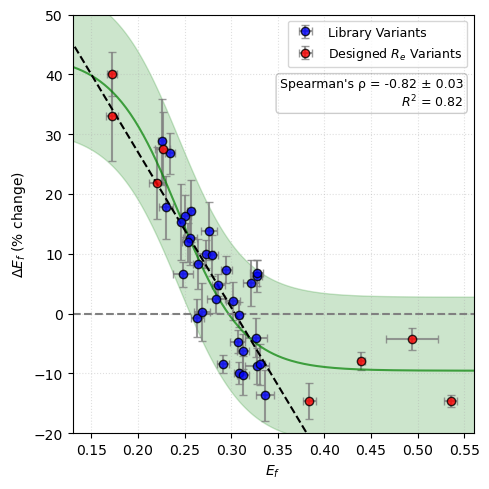

In [4]:
construct_stats['Ef_cell_perc_change'] = construct_stats['Ef_cell_delta'] / construct_stats['Ef_cell']
construct_stats['Ef_cell_perc_change_std'] = abs(construct_stats['Ef_cell_perc_change']) * np.sqrt(
    (construct_stats['Ef_cell_delta_std'] / construct_stats['Ef_cell_delta'])**2 + 
    (construct_stats['Ef_cell_std'] / construct_stats['Ef_cell'])**2
)

# First, calculate the linear fit from constructs < 33 for overlay
library_stats = construct_stats[construct_stats['construct'] < 33].copy()
library_fit_data = library_stats[['Ef_cell', 'Ef_cell_perc_change']].dropna()
x_library = library_fit_data['Ef_cell'].values
y_library = library_fit_data['Ef_cell_perc_change'].values * 100  # Convert to percentage

def linear_function(x, slope, intercept):
    return slope * x + intercept

popt_linear, pcov_linear = curve_fit(linear_function, x_library, y_library)
slope_linear, intercept_linear = popt_linear

# Now proceed with sigmoid fit on all data
def sigmoid_function(x, n, k, x0, y_offset):
    return n * (1 / (1 + np.exp(k * (x - x0)))) + y_offset

# Prepare data for fitting (using proportion, not percentage)
fit_data = construct_stats[['Ef_cell', 'Ef_cell_perc_change']].dropna()
x_data = fit_data['Ef_cell'].values
y_data = fit_data['Ef_cell_perc_change'].values

# Monte Carlo sampling for Spearman correlation
n_iterations = 1000
spearman_values = []

for _ in range(n_iterations):
    sampled_x = []
    sampled_y = []
    
    for idx, row in fit_data.iterrows():
        # Sample from normal distributions based on mean and std for each construct
        sampled_x_val = np.random.normal(construct_stats.loc[idx, 'Ef_cell'], 
                                        construct_stats.loc[idx, 'Ef_cell_std'])
        sampled_y_val = np.random.normal(construct_stats.loc[idx, 'Ef_cell_perc_change'], 
                                         construct_stats.loc[idx, 'Ef_cell_perc_change_std'])
        
        sampled_x.append(sampled_x_val)
        sampled_y.append(sampled_y_val)
    
    # Calculate Spearman correlation for this iteration
    if len(sampled_x) == len(fit_data):
        spearman_rho_sample, _ = spearmanr(sampled_x, sampled_y)
        spearman_values.append(spearman_rho_sample)

# Calculate mean and std of Spearman correlations
spearman_rho_mean = np.mean(spearman_values)
spearman_rho_std = np.std(spearman_values)

# Initial guesses: amplitude, steepness (negative for reversed), midpoint, vertical offset
initial_guess = [0.6, -20, 0.35, -0.2]
bounds = ([-2, -100, 0.0, -2], [2, 0, 1.0, 2])

popt, pcov = curve_fit(sigmoid_function, x_data, y_data,
                       p0=initial_guess, bounds=bounds, maxfev=10000)

n, k, x0, y_offset = popt
std_err = np.sqrt(np.diag(pcov))

# Calculate residual standard error and R-squared
residuals = y_data - sigmoid_function(x_data, *popt)
residual_std = np.sqrt(np.sum(residuals**2) / (len(x_data) - len(popt)))
ss_res = np.sum(residuals**2)
ss_tot = np.sum((y_data - np.mean(y_data))**2)
r_squared = 1 - (ss_res / ss_tot)

# Calculate 95% confidence interval
alpha = 0.05
n_points = len(x_data)
dof = max(1, n_points - len(popt))
t_val = t.ppf(1 - alpha/2, dof)

# Generate smooth curve for plotting
x_fit = np.linspace(x_data.min() - 0.05, x_data.max() + 0.05, 200)
y_fit = sigmoid_function(x_fit, n, k, x0, y_offset)

# Confidence band using residual error
y_upper = y_fit + t_val * residual_std
y_lower = y_fit - t_val * residual_std

# Convert to percentage for display
construct_stats['Ef_cell_perc_change_display'] = construct_stats['Ef_cell_perc_change'] * 100
construct_stats['Ef_cell_perc_change_std_display'] = construct_stats['Ef_cell_perc_change_std'] * 100

fig, ax = plt.subplots(figsize=(5, 5))

# Split data into two groups
blue_mask = construct_stats['construct'] < 35
red_mask = (construct_stats['construct'] >= 35) & (construct_stats['construct'] <= 42)

# Plot blue points (Library Variants)
ax.errorbar(construct_stats.loc[blue_mask, 'Ef_cell'], 
            construct_stats.loc[blue_mask, 'Ef_cell_perc_change_display'], 
            xerr=construct_stats.loc[blue_mask, 'Ef_cell_std'],
            yerr=construct_stats.loc[blue_mask, 'Ef_cell_perc_change_std_display'],
            fmt='o', color='blue', markeredgecolor='black', markeredgewidth=1,
            ecolor='grey', capsize=3, alpha=0.8, label='Library Variants')

# Plot red points (Designed Re Variants)
ax.errorbar(construct_stats.loc[red_mask, 'Ef_cell'], 
            construct_stats.loc[red_mask, 'Ef_cell_perc_change_display'], 
            xerr=construct_stats.loc[red_mask, 'Ef_cell_std'],
            yerr=construct_stats.loc[red_mask, 'Ef_cell_perc_change_std_display'],
            fmt='o', color='red', markeredgecolor='black', markeredgewidth=1,
            ecolor='grey', capsize=3, alpha=0.8, label='Designed $R_e$ Variants')

# Plot sigmoid fit line and confidence interval (convert to percentage)
ax.plot(x_fit, y_fit * 100, color='green', linewidth=1.5, alpha=0.7, zorder=2)
ax.fill_between(x_fit, y_lower * 100, y_upper * 100, color='green', alpha=0.2, zorder=1)

# Plot linear fit from constructs < 33 as dashed black line
x_linear_fit = np.linspace(.12, .57, 200)
y_linear_fit = linear_function(x_linear_fit, slope_linear, intercept_linear)
ax.plot(x_linear_fit, y_linear_fit, color='black', linestyle='--', linewidth=1.5, alpha=1, zorder=2)

ax.axhline(0, linestyle='--', color='gray')

ax.set_xlabel(r'$E_{f}$')
ax.set_ylabel(r'Δ$E_{f}$ (% change)')
ax.grid(True, linestyle=':', alpha=0.4)

# Add legend to top right
ax.legend(loc='upper right', frameon=True, fontsize=9)

# Add Spearman correlation text with Monte Carlo error
ax.text(0.975, 0.85, f"Spearman's ρ = {spearman_rho_mean:.2f} ± {spearman_rho_std:.2f}\n$R^2$ = {r_squared:.2f}", 
        transform=ax.transAxes, fontsize=9, verticalalignment='top', 
        horizontalalignment='right', bbox=dict(boxstyle='round', facecolor='white', alpha=0.2))

plt.xlim(.13, .56)
plt.ylim(-20, 50)

plt.tight_layout()
#plt.savefig('Ef_vs_deltaEf_1-40.svg')